# Market Signal Analysis - Volatile Sample

This notebook performs a simple market time-series analysis using sample price data.

The goal is to demonstrate basic data loading, timestamp cleaning, feature engineering, and visual inspection of price and volatility.


In [84]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys

sys.path.append(str(Path.cwd().parent / "src"))

from metrics import (
    calculate_returns,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_sharpe_like,
)
from signals import momentum_signal, mean_reversion_signal

dataset_file = "volatile_sample_prices.csv"
data_path = Path("../data") / dataset_file

print(f"Using dataset: {dataset_file}")

df = pd.read_csv(data_path)

df.head()

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

df.info()


Using dataset: volatile_sample_prices.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72 entries, 2024-01-01 00:00:00 to 2024-01-03 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   72 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB


## Feature engineering


In [85]:
rolling_window = 24

df["return"] = calculate_returns(df["close"])
df["rolling_mean"] = df["close"].rolling(window=rolling_window).mean()
df["rolling_volatility"] = df["return"].rolling(window=rolling_window).std()
df["rolling_std"] = df["close"].rolling(window=rolling_window).std()
df["z_score"] = (df["close"] - df["rolling_mean"]) / df["rolling_std"]
df.head(30)

,close,return,rolling_mean,rolling_volatility,rolling_std,z_score
timestamp,,,,,,
2024-01-01 00:00:00,101.1643,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,101.0332,-0.001296,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,101.2047,0.001697,NaN,NaN,NaN,NaN
2024-01-01 03:00:00,101.6040,0.003945,NaN,NaN,NaN,NaN
2024-01-01 04:00:00,101.2754,-0.003234,NaN,NaN,NaN,NaN
2024-01-01 05:00:00,101.4286,0.001513,NaN,NaN,NaN,NaN
2024-01-01 06:00:00,101.5802,0.001495,NaN,NaN,NaN,NaN
2024-01-01 07:00:00,100.6631,-0.009028,NaN,NaN,NaN,NaN
2024-01-01 08:00:00,101.4287,0.007606,NaN,NaN,NaN,NaN


## Price chart


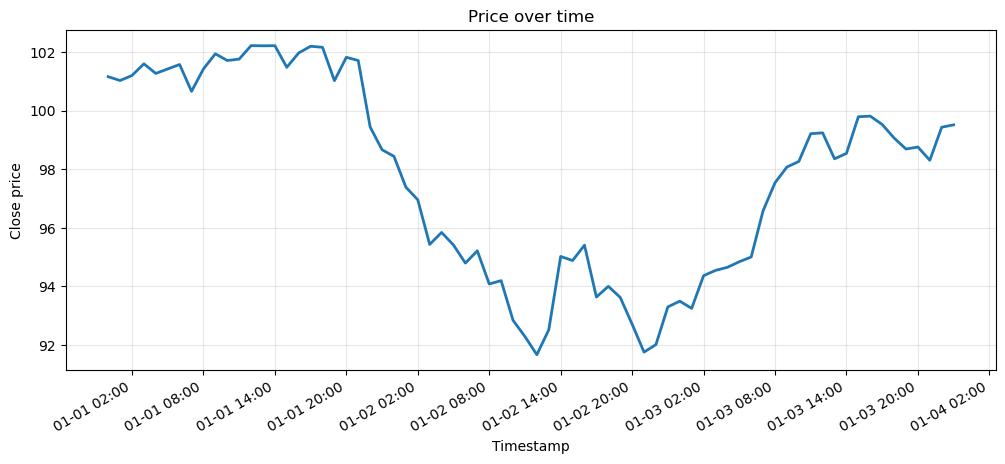

In [86]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["close"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Price over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Close price")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Rolling volatility chart

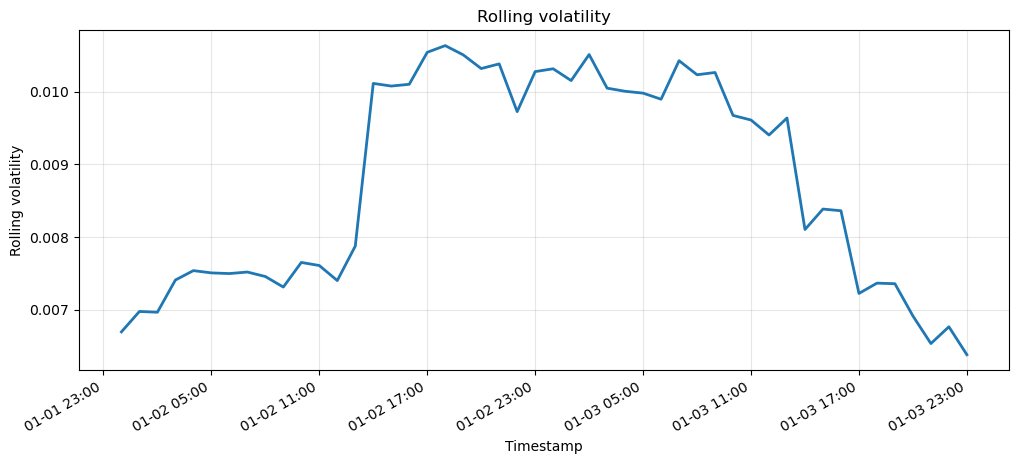

In [87]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["rolling_volatility"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Rolling volatility")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling volatility")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Initial observations

The dataset is sorted by timestamp and indexed as a time series.  
The return column measures percentage price changes between consecutive observations.  
Rolling volatility is calculated as the rolling standard deviation of returns.

At this stage, the notebook only performs basic exploratory analysis. No trading signal or backtest is included yet.


## Momentum signal

A simple momentum signal is based on recent returns.  
If the rolling return is positive, the signal is long. If it is negative, the signal is short.


In [88]:
signal_window = 12

df["momentum_signal"] = momentum_signal(df["return"], window=signal_window)

df[["return", "momentum_signal"]].tail()


,return,momentum_signal
timestamp,,
2024-01-03 19:00:00,-0.003800,1
2024-01-03 20:00:00,0.000699,1
2024-01-03 21:00:00,-0.004580,1
2024-01-03 22:00:00,0.011486,1
2024-01-03 23:00:00,0.000804,1


## Backtest setup

The signal is shifted by one period before calculating momentum returns.  
This avoids using information from the current bar to trade the same bar.


In [89]:
df["momentum_position"] = df["momentum_signal"].shift(1)

df[["momentum_signal", "momentum_position"]].tail()


,momentum_signal,momentum_position
timestamp,,
2024-01-03 19:00:00,1,1.0
2024-01-03 20:00:00,1,1.0
2024-01-03 21:00:00,1,1.0
2024-01-03 22:00:00,1,1.0
2024-01-03 23:00:00,1,1.0


## Momentum returns

Momentum returns are calculated by multiplying the shifted position by the market return.


In [90]:
df["momentum_return"] = df["momentum_position"] * df["return"]
df["momentum_equity_curve"] = (1 + df["momentum_return"].fillna(0)).cumprod()

df[["return", "momentum_position", "momentum_return", "momentum_equity_curve"]].tail()


,return,momentum_position,momentum_return,momentum_equity_curve
timestamp,,,,
2024-01-03 19:00:00,-0.003800,1.0,-0.003800,1.121570
2024-01-03 20:00:00,0.000699,1.0,0.000699,1.122354
2024-01-03 21:00:00,-0.004580,1.0,-0.004580,1.117214
2024-01-03 22:00:00,0.011486,1.0,0.011486,1.130046
2024-01-03 23:00:00,0.000804,1.0,0.000804,1.130954


## Momentum metrics

The metrics summarize the simplified momentum backtest.


In [91]:
metrics = {
    "cumulative_return": df["momentum_equity_curve"].iloc[-1] - 1,
    "max_drawdown": calculate_max_drawdown(df["momentum_equity_curve"]),
    "win_rate": calculate_win_rate(df["momentum_return"]),
    "sharpe_like": calculate_sharpe_like(
        df["momentum_return"],
        periods_per_year=24 * 365,
    ),
}

metrics


{'cumulative_return': 0.1309542238144359,
 'max_drawdown': -0.04004635344896046,
 'win_rate': 0.49295774647887325,
 'sharpe_like': 21.144415632655214}

## Momentum equity curve


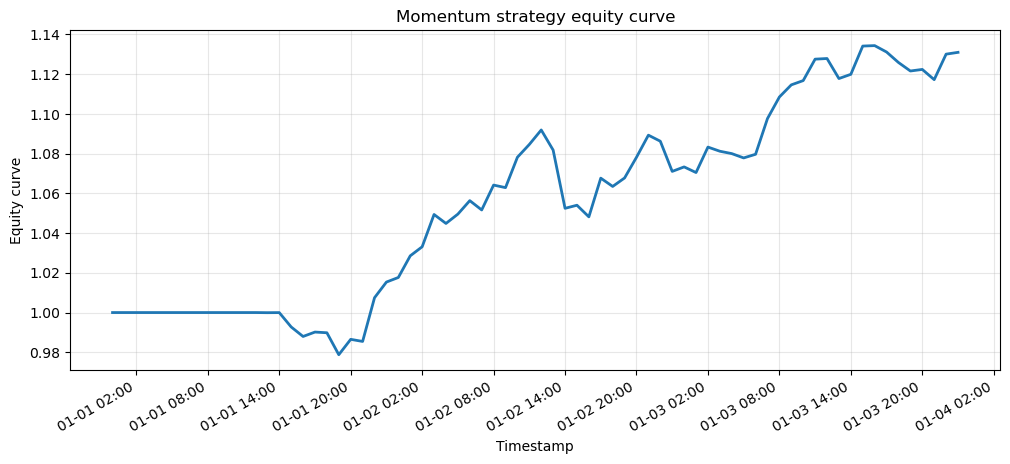

In [92]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["momentum_equity_curve"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy equity curve")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Equity curve")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Transaction costs

The raw backtest assumes zero trading costs.  
To make the model slightly more realistic, a small cost is charged whenever the strategy changes position.

In [93]:
transaction_cost = 0.001

df["momentum_position_change"] = df["momentum_position"].diff().abs()
df["momentum_transaction_cost"] = (
    df["momentum_position_change"] * transaction_cost
)

df["momentum_return_after_costs"] = (
    df["momentum_return"] - df["momentum_transaction_cost"]
)

df["momentum_equity_curve_after_costs"] = (
    1 + df["momentum_return_after_costs"].fillna(0)
).cumprod()

df[
    [
        "momentum_position",
        "momentum_position_change",
        "momentum_transaction_cost",
        "momentum_return",
        "momentum_return_after_costs",
        "momentum_equity_curve",
        "momentum_equity_curve_after_costs",
    ]
].tail()

,momentum_position,momentum_position_change,momentum_transaction_cost,momentum_return,momentum_return_after_costs,momentum_equity_curve,momentum_equity_curve_after_costs
timestamp,,,,,,,
2024-01-03 19:00:00,1.0,0.0,0.0,-0.003800,-0.003800,1.121570,1.107116
2024-01-03 20:00:00,1.0,0.0,0.0,0.000699,0.000699,1.122354,1.107890
2024-01-03 21:00:00,1.0,0.0,0.0,-0.004580,-0.004580,1.117214,1.102817
2024-01-03 22:00:00,1.0,0.0,0.0,0.011486,0.011486,1.130046,1.115484
2024-01-03 23:00:00,1.0,0.0,0.0,0.000804,0.000804,1.130954,1.116380


The transaction cost is applied only when the position changes.

A change from flat to long or flat to short costs one unit of transaction cost.  
A direct flip from long to short costs two units because the exposure changes from `1` to `-1`.

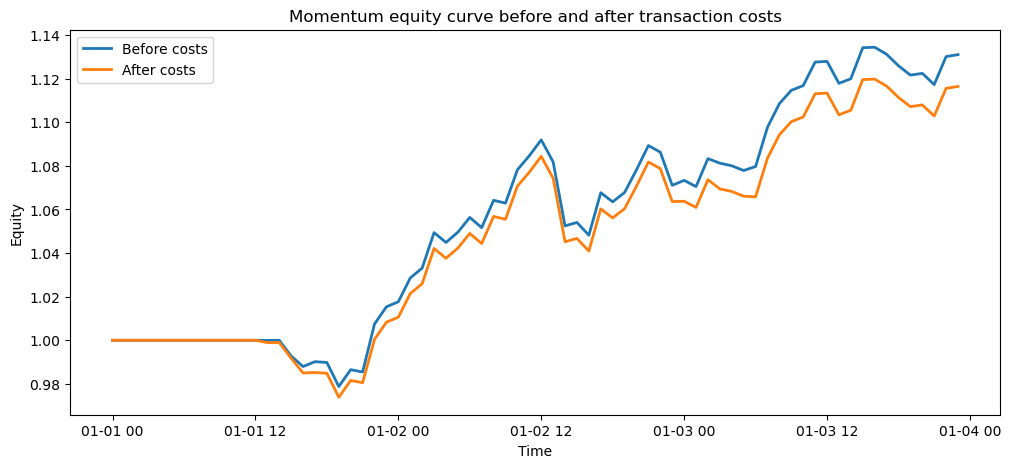

In [94]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df.index,
    df["momentum_equity_curve"],
    label="Before costs",
    linewidth=2.0,
)

ax.plot(
    df.index,
    df["momentum_equity_curve_after_costs"],
    label="After costs",
    linewidth=2.0,
)

ax.set_title("Momentum equity curve before and after transaction costs")
ax.set_xlabel("Time")
ax.set_ylabel("Equity")
ax.legend()

plt.show()

Transaction costs reduce the final equity curve because the strategy pays a small penalty whenever it trades.

This is still a simplified cost model. It does not include bid-ask spread, slippage, liquidity, or market impact, but it is more realistic than assuming free trading.

## Backtest interpretation

The momentum signal produces a positive cumulative return on this sample dataset.

This result should be interpreted carefully. The dataset is small and trends upward, which makes a momentum signal look better than it would on a broader market sample.

The backtest also uses simplified execution assumptions and does not include transaction costs, slippage, liquidity constraints, or out-of-sample validation.


## Momentum drawdown


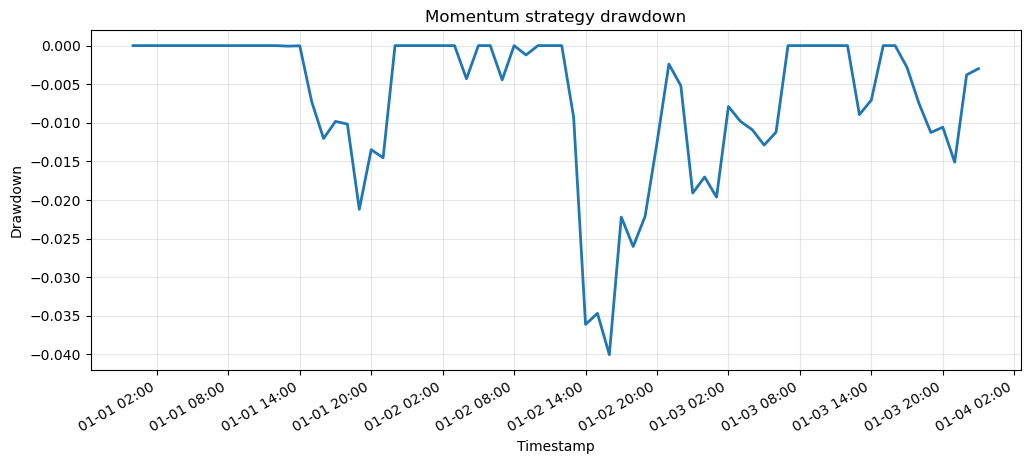

In [95]:
running_max = df["momentum_equity_curve"].cummax()
df["drawdown"] = df["momentum_equity_curve"] / running_max - 1

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["drawdown"], linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy drawdown")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Drawdown")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Momentum position


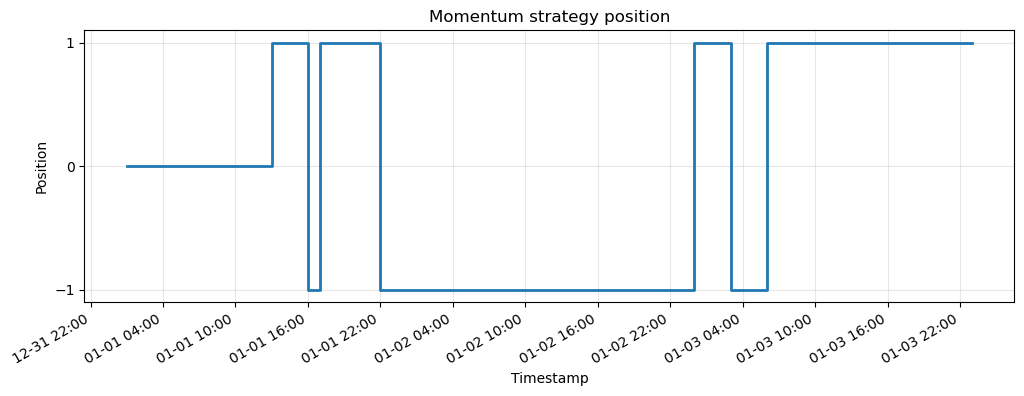

In [96]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.step(df.index, df["momentum_position"], where="post", linewidth=2.0, zorder=3)
ax.grid(True, alpha=0.3, zorder=0)

ax.set_title("Momentum strategy position")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Position")
ax.set_yticks([-1, 0, 1])
ax.grid(True)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()


## Mean reversion signal

The mean reversion signal uses the z-score of price versus its rolling mean.

If the price is far below the rolling mean, the signal goes long.  
If the price is far above the rolling mean, the signal goes short.

In [97]:
mean_reversion_threshold = 1.0

df["mean_reversion_signal"] = mean_reversion_signal(
    df["z_score"],
    entry_threshold=mean_reversion_threshold,
)

df[["z_score", "mean_reversion_signal"]].tail()

,z_score,mean_reversion_signal
timestamp,,
2024-01-03 19:00:00,0.845301,0
2024-01-03 20:00:00,0.799970,0
2024-01-03 21:00:00,0.569908,0
2024-01-03 22:00:00,0.966736,0
2024-01-03 23:00:00,0.933534,0


## Mean reversion backtest

The mean reversion position is shifted by one period before calculating momentum returns.

In [98]:
df["mean_reversion_position"] = df["mean_reversion_signal"].shift(1)

df["mean_reversion_return"] = df["mean_reversion_position"] * df["return"]
df["mean_reversion_equity_curve"] = (
    1 + df["mean_reversion_return"].fillna(0)
).cumprod()

df[
    [
        "return",
        "mean_reversion_position",
        "mean_reversion_return",
        "mean_reversion_equity_curve",
    ]
].tail()

,return,mean_reversion_position,mean_reversion_return,mean_reversion_equity_curve
timestamp,,,,
2024-01-03 19:00:00,-0.003800,-1.0,0.0038,0.932204
2024-01-03 20:00:00,0.000699,0.0,0.0000,0.932204
2024-01-03 21:00:00,-0.004580,0.0,-0.0000,0.932204
2024-01-03 22:00:00,0.011486,0.0,0.0000,0.932204
2024-01-03 23:00:00,0.000804,0.0,0.0000,0.932204


## Mean reversion equity curve

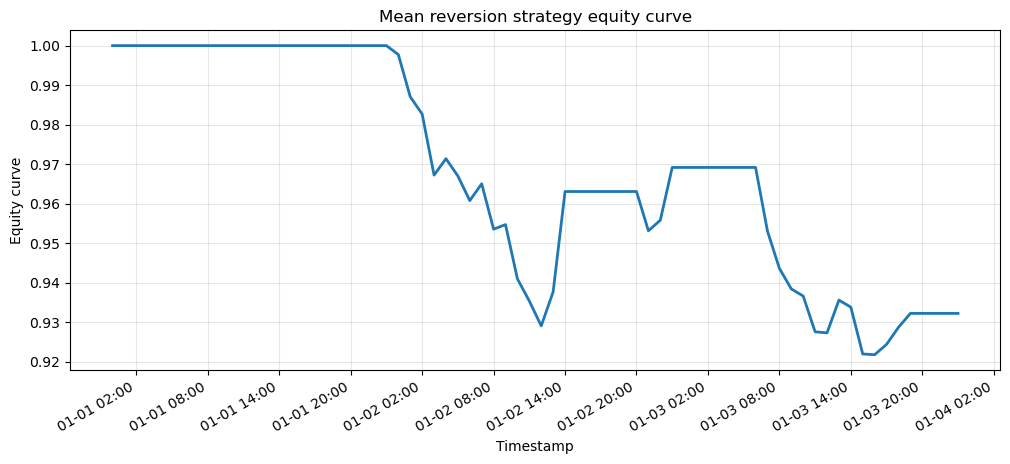

In [99]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["mean_reversion_equity_curve"], linewidth=2.0, zorder=3)

ax.set_title("Mean reversion strategy equity curve")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Equity curve")
ax.grid(True, alpha=0.3, zorder=0)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

fig.autofmt_xdate()
plt.show()

## Strategy comparison

The table compares momentum and mean reversion using the same simplified metrics.

In [100]:
strategy_comparison = pd.DataFrame(
    [
        {
            "strategy": "momentum",
            "cumulative_return": df["momentum_equity_curve"].iloc[-1] - 1,
            "max_drawdown": calculate_max_drawdown(df["momentum_equity_curve"]),
            "win_rate": calculate_win_rate(df["momentum_return"]),
            "sharpe_like": calculate_sharpe_like(
                df["momentum_return"],
                periods_per_year=24 * 365,
            ),
        },
        {
            "strategy": "mean_reversion",
            "cumulative_return": df["mean_reversion_equity_curve"].iloc[-1] - 1,
            "max_drawdown": calculate_max_drawdown(
                df["mean_reversion_equity_curve"]
            ),
            "win_rate": calculate_win_rate(df["mean_reversion_return"]),
            "sharpe_like": calculate_sharpe_like(
                df["mean_reversion_return"],
                periods_per_year=24 * 365,
            ),
        },
    ]
)

strategy_comparison

,strategy,cumulative_return,max_drawdown,win_rate,sharpe_like
0,momentum,0.130954,-0.040046,0.492958,21.144416
1,mean_reversion,-0.067796,-0.078251,0.154930,-14.407368


The table compares both signal types using the same simplified backtest metrics. This makes it easier to see how different market assumptions behave on the same price series.

## Interpretation

On this volatile sample, the momentum signal performs better than the mean reversion signal.

The momentum approach benefits from larger directional moves in the dataset. The mean reversion approach enters against deviations from the rolling mean, but some of those deviations continue before reversing, which leads to weaker performance and deeper drawdowns.

This does not mean momentum is generally better than mean reversion. The result is specific to this small synthetic dataset and should be treated as an illustration of how different signal assumptions can produce different backtest behavior.